In [2]:

def run(num):
    import numpy as np
    import scipy
    import os
    import time
    from tqdm import tqdm
    import pandas as pd
    sig_length = 20

    given_params = ['WOW', 'LATP', 'LONP', 'BAL1', 'ROLL', 'PTCH', 'IVV', 'GS', 'CAS', 'VRTG', 'LATG', 'FLAP', 'PLA_2', 'PLA_3', 'PLA_4', 'TRK', 'TH', 'WS', 'WD', 'TAT', 'SAT', 'LOC', 'GLS']


    def find_index(arr):
        left, right = 0, len(arr) - 1
        idx_l = -1
        while left <= right:
            mid = left + (right - left) // 2
            if arr[mid] == 1:
                left = mid + 1
            elif arr[mid] == 0:
                if mid > 0 and arr[mid - 1] == 1:
                    idx_l = mid
                    break
                if arr[:mid].sum() == 0:
                    left = mid + 1
                else:
                    right = mid - 1

        if arr[idx_l:].sum() == 0:
            return idx_l
        return find_index(arr[idx_l+1:]) + idx_l + 1



    data_num = num


    import os
    import scipy.io
    import numpy as np
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from tqdm import tqdm

    # Define necessary paths and parameters
    dataset_folder = "../../../data/small_data{}".format(data_num)
    folder_list = [folder for folder in os.listdir(dataset_folder) if "Tail" in folder]

    required_data = []
    timestamps = []

    # Define a function to process each timestamp
    def process_timestamp(flight_path, timestamp, given_params, sig_length):
        try:
            # Load the .mat file
            data = scipy.io.loadmat(os.path.join(flight_path, timestamp))
        except:
            return None, None  # Skip files that can't be loaded

        # Find length and touchdown index
        length = len(data['WOW'][0][0][0])
        try:
            touch_down_index = find_index(data['WOW'][0][0][0])
        except:
            # Fallback for finding touch down index if find_index fails
            temp_data = data['WOW'][0][0][0][::-1]
            idx = next((i for i, val in enumerate(temp_data) if val == 1), -1)
            touch_down_index = length - 1 - idx if idx != -1 else None
            if touch_down_index is None:
                return None, None

        # Extract and downsample data
        lis_data = []
        for param in given_params:
            signal = data[param][0][0][0].flatten()
            length_signal = len(signal)
            signal_mul_factor = length_signal // length
            down_sampled_signal = np.mean(signal.reshape(-1, signal_mul_factor), axis=1)
            required_signal = down_sampled_signal[touch_down_index - sig_length : touch_down_index + 1]
            lis_data.append(required_signal)

        flight_data = np.array(lis_data)
        return flight_data.flatten() if flight_data.size > 0 else None, timestamp

    # Main processing function
    def process_flight(flight_idx, flight, given_params, sig_length):
        flight_path = os.path.join(dataset_folder, flight)
        flight_data_list = []

        with ThreadPoolExecutor(max_workers=20) as executor:
            futures = {
                executor.submit(process_timestamp, flight_path, timestamp, given_params, sig_length): timestamp
                for timestamp in os.listdir(flight_path)
            }
            
            for future in tqdm(as_completed(futures), total=len(futures), desc=f"Flight {flight_idx}"):
                flight_data, timestamp = future.result()
                if flight_data is not None:
                    flight_data_list.append((flight_data, timestamp))

        return flight_data_list

    # Aggregate data for all flights
    all_flight_data = []
    for flight_idx, flight in enumerate(folder_list):
        flight_data_list = process_flight(flight_idx, flight, given_params, sig_length)
        for data, timestamp in flight_data_list:
            required_data.append(data)
            timestamps.append(timestamp)
            
            
    r = []
    t = []
    for i in range(len(required_data)):
        if len(required_data[i]) == 483:
            r.append(required_data[i])
            t.append(timestamps[i])
    required_data = r
    timestamps = t


    required_data = np.array(required_data)

    var_names = [x+"-"+str(y) for x in given_params for y in range(sig_length, -1, -1)] + ["touchdown_distance"]

    print(len(var_names))

    touchdown_data = pd.read_csv("LongLandingCompressed.csv", index_col=0)
    touchdown_data.set_index("Timestamps", inplace=True)

    available_indices = []
    for i in range(len(timestamps)):
        if timestamps[i] in touchdown_data.index:
            available_indices.append(i)
            
            
    t = []
    for i in available_indices:
        t.append(timestamps[i])
    r = required_data[available_indices]

    timestamps = t
    required_data = r


    touchdown_distances = touchdown_data.loc[timestamps, "distance_km"].to_numpy()
    required_data = np.c_[required_data, touchdown_distances]


    print(len(required_data))


    # save data
    np.save(f"required_data{data_num}.npy", required_data)

    timestamps_save_file = f"timestamps_save_file{data_num}.txt"
    with open(timestamps_save_file, "w") as f:
        for item in timestamps:
            f.write(f"{item}\n")

In [3]:
run(1)

Flight 34: 100%|██████████| 502/502 [00:19<00:00, 25.50it/s]


484
16252


In [4]:
run(2)

Flight 38: 100%|██████████| 678/678 [00:24<00:00, 28.07it/s]
Flight 39: 0it [00:00, ?it/s]
Flight 40: 100%|██████████| 218/218 [00:06<00:00, 33.03it/s]


484
18542


In [5]:
run(3)

Flight 21: 100%|██████████| 519/519 [00:21<00:00, 24.62it/s]


484
10484


In [6]:
run(4)

Flight 19: 100%|██████████| 460/460 [00:15<00:00, 30.43it/s]


484
9544


In [7]:
run(5)

Flight 23: 100%|██████████| 439/439 [00:18<00:00, 23.75it/s]


484
11613


In [8]:
run(6)

Flight 26: 100%|██████████| 144/144 [00:04<00:00, 31.13it/s]
Flight 27: 0it [00:00, ?it/s]
Flight 33: 100%|██████████| 674/674 [00:24<00:00, 27.08it/s]


484
15487


In [9]:
run(7)

Flight 31: 100%|██████████| 633/633 [00:20<00:00, 31.35it/s]


484
16096


In [10]:
run(8)

Flight 1: 100%|██████████| 237/237 [00:07<00:00, 32.30it/s]
Flight 2: 0it [00:00, ?it/s]
Flight 36: 100%|██████████| 662/662 [00:28<00:00, 23.62it/s]


484
17194


In [11]:
run(9)

Flight 33: 100%|██████████| 712/712 [00:21<00:00, 32.81it/s]


484
16194


In [12]:
run(10)

Flight 8: 100%|██████████| 396/396 [00:15<00:00, 25.19it/s]


484
4386


In [13]:
# I have data stored as required_data1.npy, required_data2.npy, ... required_data10.npy
# Combine them into one file combined_required_data.npy

import numpy as np

data = np.load("required_data1.npy")
for i in range(2, 11):
    data = np.concatenate((data, np.load(f"required_data{i}.npy")))
    
np.save("combined_required_data.npy", data)

In [3]:
given_paramss = ['WOW', 'LATP', 'LONP', 'BAL1', 'ROLL', 'PTCH', 'IVV', 'GS', 'CAS', 'VRTG', 'LATG', 'FLAP', 'PLA_2', 'PLA_3', 'PLA_4', 'TRK', 'TH', 'WS', 'WD', 'TAT', 'SAT', 'LOC', 'GLS']
sig_lengthh = 20  # Adjust this based on your signal length
var_namess = [f"{x}-{y}" for x in given_paramss for y in range(sig_lengthh, -1, -1)] + ["touchdown_distance"]

len(given_paramss),len(var_namess)

(23, 484)

In [14]:
import numpy as np
import scipy
import os
import time
from tqdm import tqdm
import pandas as pd
sig_length = 20
from causalai.models.tabular.pc import PCSingle
from causalai.models.tabular.grow_shrink import GrowShrink

from causalai.models.common.CI_tests.partial_correlation import PartialCorrelation
from causalai.models.common.CI_tests.discrete_ci_tests import DiscreteCI_tests
from causalai.models.common.CI_tests.kci import KCI

from causalai.data.tabular import TabularData
from causalai.data.transforms.time_series import StandardizeTransform
from causalai.models.common.prior_knowledge import PriorKnowledge


/mnt/d/Honeywell/Honeywell Analysis/Honeywell Analysis/new_work/aditya/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-12 17:00:50,186	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [15]:
import numpy as np
from causalai.data.tabular import TabularData

# Load your data
required_data = np.load("combined_required_data.npy")

# Define variable names
given_params = ['WOW', 'LATP', 'LONP', 'BAL1', 'ROLL', 'PTCH', 'IVV', 'GS', 'CAS', 'VRTG', 'LATG', 'FLAP', 'PLA_2', 'PLA_3', 'PLA_4', 'TRK', 'TH', 'WS', 'WD', 'TAT', 'SAT', 'LOC', 'GLS']
sig_length = 20  # Adjust this based on your signal length
var_names = [f"{x}-{y}" for x in given_params for y in range(sig_length, -1, -1)] + ["touchdown_distance"]

# Create TabularData object
data_obj = TabularData(required_data, var_names=var_names)


In [16]:
required_data.shape

(135792, 484)

In [17]:
from causalai.models.tabular.grow_shrink import GrowShrink
from causalai.models.common.CI_tests.partial_correlation import PartialCorrelation
from causalai.models.common.prior_knowledge import PriorKnowledge

# Initialize the conditional independence test
CI_test = PartialCorrelation()

# Define prior knowledge if any (optional)
prior_knowledge = None  # Replace with PriorKnowledge object if you have prior knowledge

# Initialize the GrowShrink object
gs = GrowShrink(
    data=data_obj,
    prior_knowledge=prior_knowledge,
    CI_test=CI_test,
    use_multiprocessing=False
)


In [18]:
# Define parameters
target_var = 'touchdown_distance'  # Variable of interest
pvalue_thres = 0.05  # Significance level for independence tests

# Run the Grow-Shrink algorithm
result = gs.run(
    target_var=target_var,
    pvalue_thres=pvalue_thres
)

# Extract the Markov blanket and associated weights
markov_blanket = result['markov_blanket']
value_dict = result['value_dict']
pvalue_dict = result['pvalue_dict']

# Display the results
print(f"Markov Blanket of {target_var}: {markov_blanket}")
print("\nAssociations and Weights:")
for var in markov_blanket:
    print(f"{var} -> {target_var}: Test Statistic = {value_dict[var]:.4f}, p-value = {pvalue_dict[var]:.4f}")


/mnt/d/Honeywell/Honeywell Analysis/Honeywell Analysis/new_work/aditya/lib/python3.11/site-packages/causalai/models/common/CI_tests/partial_correlation.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_residual, y_residual)


Markov Blanket of touchdown_distance: ['CAS-20', 'IVV-1', 'GLS-3', 'GLS-2', 'PTCH-8', 'PLA_2-0', 'GLS-5', 'GS-7', 'GLS-7', 'PLA_2-14', 'PLA_2-13', 'GLS-6', 'IVV-0', 'WS-8', 'PTCH-0', 'GLS-1', 'LATG-20', 'LATP-18', 'LONP-6', 'TAT-0', 'PLA_3-14', 'GLS-0', 'CAS-8', 'SAT-6', 'GS-4', 'VRTG-4', 'LATP-16', 'PLA_3-13', 'WOW-0', 'GLS-4', 'IVV-3', 'LATG-0', 'LATG-5', 'IVV-2']

Associations and Weights:
CAS-20 -> touchdown_distance: Test Statistic = 0.0057, p-value = 0.0365
IVV-1 -> touchdown_distance: Test Statistic = -0.0082, p-value = 0.0025
GLS-3 -> touchdown_distance: Test Statistic = 0.0136, p-value = 0.0000
GLS-2 -> touchdown_distance: Test Statistic = 0.0169, p-value = 0.0000
PTCH-8 -> touchdown_distance: Test Statistic = 0.0075, p-value = 0.0056
PLA_2-0 -> touchdown_distance: Test Statistic = -0.0057, p-value = 0.0358
GLS-5 -> touchdown_distance: Test Statistic = 0.0151, p-value = 0.0000
GS-7 -> touchdown_distance: Test Statistic = 0.0059, p-value = 0.0304
GLS-7 -> touchdown_distance: Te

- 
- /mnt/d/Honeywell/Honeywell Analysis/Honeywell Analysis/new_work/aditya/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
-   from .autonotebook import tqdm as notebook_tqdm
- 2024-11-12 17:00:50,186	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
- (135792, 484)
- /mnt/d/Honeywell/Honeywell Analysis/Honeywell Analysis/new_work/aditya/lib/python3.11/site-packages/causalai/models/common/CI_tests/partial_correlation.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
-   val, _ = stats.pearsonr(x_residual, y_residual)
- Markov Blanket of touchdown_distance: ['CAS-20', 'IVV-1', 'GLS-3', 'GLS-2', 'PTCH-8', 'PLA_2-0', 'GLS-5', 'GS-7', 'GLS-7', 'PLA_2-14', 'PLA_2-13', 'GLS-6', 'IVV-0', 'WS-8', 'PTCH-0', 'GLS-1', 'LATG-20', 'LATP-18', 'LONP-6', 'TAT-0', 'PLA_3-14', 'GLS-0', 'CAS-8', 'SAT-6', 'GS-4', 'VRTG-4', 'LATP-16', 'PLA_3-13', 'WOW-0', 'GLS-4', 'IVV-3', 'LATG-0', 'LATG-5', 'IVV-2']
- 
- Associations and Weights:
- CAS-20 -> touchdown_distance: Test Statistic = 0.0057, p-value = 0.0365
- IVV-1 -> touchdown_distance: Test Statistic = -0.0082, p-value = 0.0025
- GLS-3 -> touchdown_distance: Test Statistic = 0.0136, p-value = 0.0000
- GLS-2 -> touchdown_distance: Test Statistic = 0.0169, p-value = 0.0000
- PTCH-8 -> touchdown_distance: Test Statistic = 0.0075, p-value = 0.0056
- PLA_2-0 -> touchdown_distance: Test Statistic = -0.0057, p-value = 0.0358
- GLS-5 -> touchdown_distance: Test Statistic = 0.0151, p-value = 0.0000
- GS-7 -> touchdown_distance: Test Statistic = 0.0059, p-value = 0.0304
- GLS-7 -> touchdown_distance: Test Statistic = 0.0065, p-value = 0.0160
- PLA_2-14 -> touchdown_distance: Test Statistic = 0.0089, p-value = 0.0010
- PLA_2-13 -> touchdown_distance: Test Statistic = -0.0122, p-value = 0.0000
- GLS-6 -> touchdown_distance: Test Statistic = 0.0116, p-value = 0.0000
- IVV-0 -> touchdown_distance: Test Statistic = -0.0061, p-value = 0.0240
- WS-8 -> touchdown_distance: Test Statistic = -0.0066, p-value = 0.0148
- PTCH-0 -> touchdown_distance: Test Statistic = 0.0109, p-value = 0.0001
- GLS-1 -> touchdown_distance: Test Statistic = 0.0131, p-value = 0.0000
- LATG-20 -> touchdown_distance: Test Statistic = 0.0061, p-value = 0.0241
- LATP-18 -> touchdown_distance: Test Statistic = -0.0065, p-value = 0.0162
- LONP-6 -> touchdown_distance: Test Statistic = 0.0077, p-value = 0.0044
- TAT-0 -> touchdown_distance: Test Statistic = -0.0057, p-value = 0.0371
- PLA_3-14 -> touchdown_distance: Test Statistic = -0.0073, p-value = 0.0075
- GLS-0 -> touchdown_distance: Test Statistic = 0.0078, p-value = 0.0040
- CAS-8 -> touchdown_distance: Test Statistic = 0.0086, p-value = 0.0016
- SAT-6 -> touchdown_distance: Test Statistic = -0.0063, p-value = 0.0214
- GS-4 -> touchdown_distance: Test Statistic = -0.0068, p-value = 0.0124
- VRTG-4 -> touchdown_distance: Test Statistic = -0.0060, p-value = 0.0284
- LATP-16 -> touchdown_distance: Test Statistic = 0.0070, p-value = 0.0098
- PLA_3-13 -> touchdown_distance: Test Statistic = 0.0084, p-value = 0.0021
- WOW-0 -> touchdown_distance: Test Statistic = 0.0058, p-value = 0.0326
- GLS-4 -> touchdown_distance: Test Statistic = 0.0164, p-value = 0.0000
- IVV-3 -> touchdown_distance: Test Statistic = 0.0079, p-value = 0.0039
- LATG-0 -> touchdown_distance: Test Statistic = 0.0076, p-value = 0.0051
- LATG-5 -> touchdown_distance: Test Statistic = 0.0060, p-value = 0.0266
- IVV-2 -> touchdown_distance: Test Statistic = 0.0065, p-value = 0.0165
- 

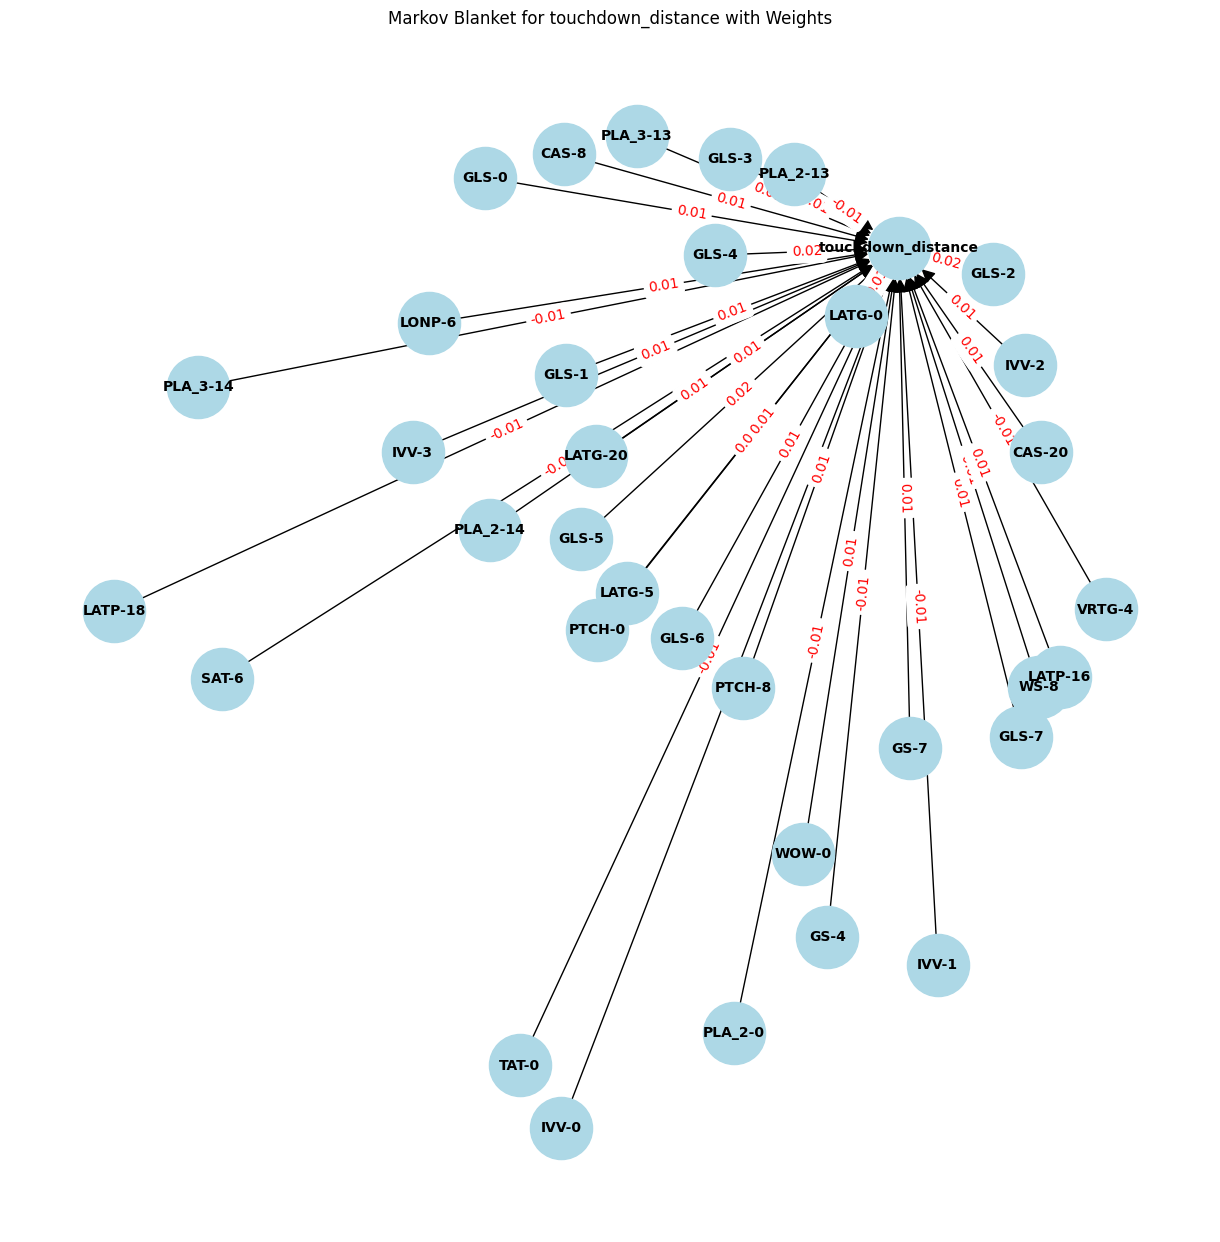

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph with weights
for var in markov_blanket:
    weight = value_dict[var]
    G.add_edge(var, target_var, weight=weight)

# Define edge labels with weights
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}

# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title(f'Markov Blanket for {target_var} with Weights')
plt.show()
